In [1]:
# ============================================
# SECCIÓN 2. EXPLORACIÓN INICIAL DEL DATASET
# Dataset: penguins
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# --------------------------------------------
# 1. Carga del dataset
# --------------------------------------------
df = sns.load_dataset("penguins").copy()

display(Markdown("## 1. Vista inicial del dataset"))
display(df.head())


## 1. Vista inicial del dataset

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.70,181.00,"3,750.00",Male
1,Adelie,Torgersen,39.50,17.40,186.00,"3,800.00",Female
2,Adelie,Torgersen,40.30,18.00,195.00,"3,250.00",Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.70,19.30,193.00,"3,450.00",Female


In [3]:
# --------------------------------------------
# 2. Número de observaciones y variables
# --------------------------------------------
n_obs, n_vars = df.shape

display(Markdown("## 2. Dimensiones del dataset"))
print(f"Número de observaciones: {n_obs}")
print(f"Número de variables: {n_vars}")

## 2. Dimensiones del dataset

Número de observaciones: 344
Número de variables: 7


In [5]:
# --------------------------------------------
# 3. Tipos de variables
# --------------------------------------------
display(Markdown("## 3. Tipos de variables"))
tipos_df = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "porcentaje_nulos": (df.isna().mean() * 100).round(2).values,
    "n_unicos": df.nunique(dropna=True).values
})
display(tipos_df)

# Separación de variables numéricas y categóricas
vars_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
vars_categoricas = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numéricas:", vars_numericas)
print("Variables categóricas:", vars_categoricas)

## 3. Tipos de variables

,variable,tipo,nulos,porcentaje_nulos,n_unicos
0,species,object,0,0.00,3
1,island,object,0,0.00,3
2,bill_length_mm,float64,2,0.58,164
3,bill_depth_mm,float64,2,0.58,80
4,flipper_length_mm,float64,2,0.58,55
5,body_mass_g,float64,2,0.58,94
6,sex,object,11,3.20,2


Variables numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Variables categóricas: ['species', 'island', 'sex']


## 4. Valores ausentes

,nulos,porcentaje
sex,11,3.20
bill_depth_mm,2,0.58
bill_length_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
island,0,0.00
species,0,0.00


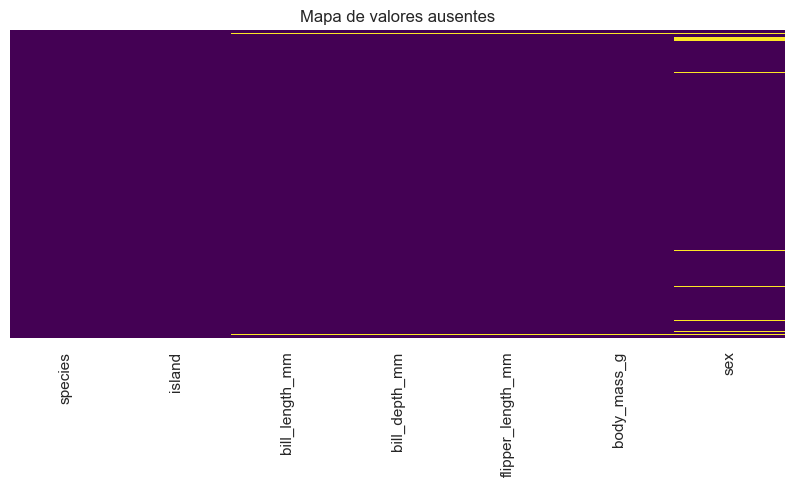

In [6]:
# --------------------------------------------
# 4. Revisión de valores nulos
# --------------------------------------------
display(Markdown("## 4. Valores ausentes"))
nulos_df = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).sort_values("nulos", ascending=False)

display(nulos_df)

# Visualización de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de valores ausentes")
plt.show()


## 5. Distribución de la variable species

,species,frecuencia,porcentaje
0,Adelie,152,44.19
1,Gentoo,124,36.05
2,Chinstrap,68,19.77


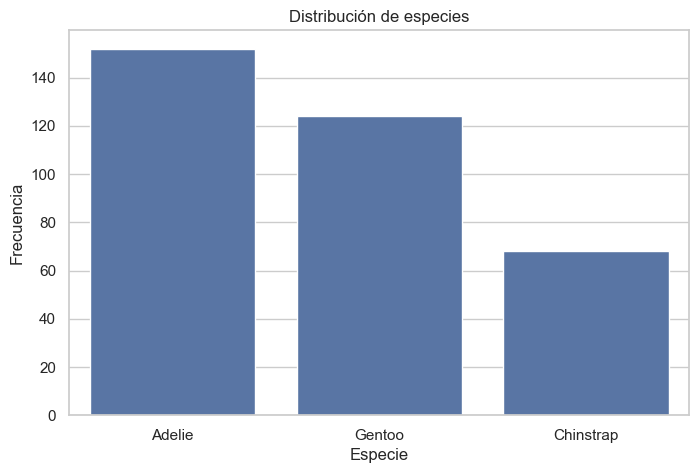

In [7]:
# --------------------------------------------
# 5. Distribución de especies
# --------------------------------------------
display(Markdown("## 5. Distribución de la variable species"))
species_freq = df["species"].value_counts(dropna=False).rename_axis("species").reset_index(name="frecuencia")
species_freq["porcentaje"] = (species_freq["frecuencia"] / len(df) * 100).round(2)
display(species_freq)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="species", order=df["species"].value_counts().index)
plt.title("Distribución de especies")
plt.xlabel("Especie")
plt.ylabel("Frecuencia")
plt.show()

In [8]:
# --------------------------------------------
# 6. Estadísticas descriptivas de variables físicas
# --------------------------------------------
display(Markdown("## 6. Estadísticas descriptivas de las variables numéricas"))
desc = df[vars_numericas].describe().T
desc["missing"] = df[vars_numericas].isna().sum()
display(desc)

## 6. Estadísticas descriptivas de las variables numéricas

,count,mean,std,min,25%,50%,75%,max,missing
bill_length_mm,342.00,43.92,5.46,32.10,39.23,44.45,48.50,59.60,2
bill_depth_mm,342.00,17.15,1.97,13.10,15.60,17.30,18.70,21.50,2
flipper_length_mm,342.00,200.92,14.06,172.00,190.00,197.00,213.00,231.00,2
body_mass_g,342.00,"4,201.75",801.95,"2,700.00","3,550.00","4,050.00","4,750.00","6,300.00",2


## 7. Visualización preliminar de medidas físicas

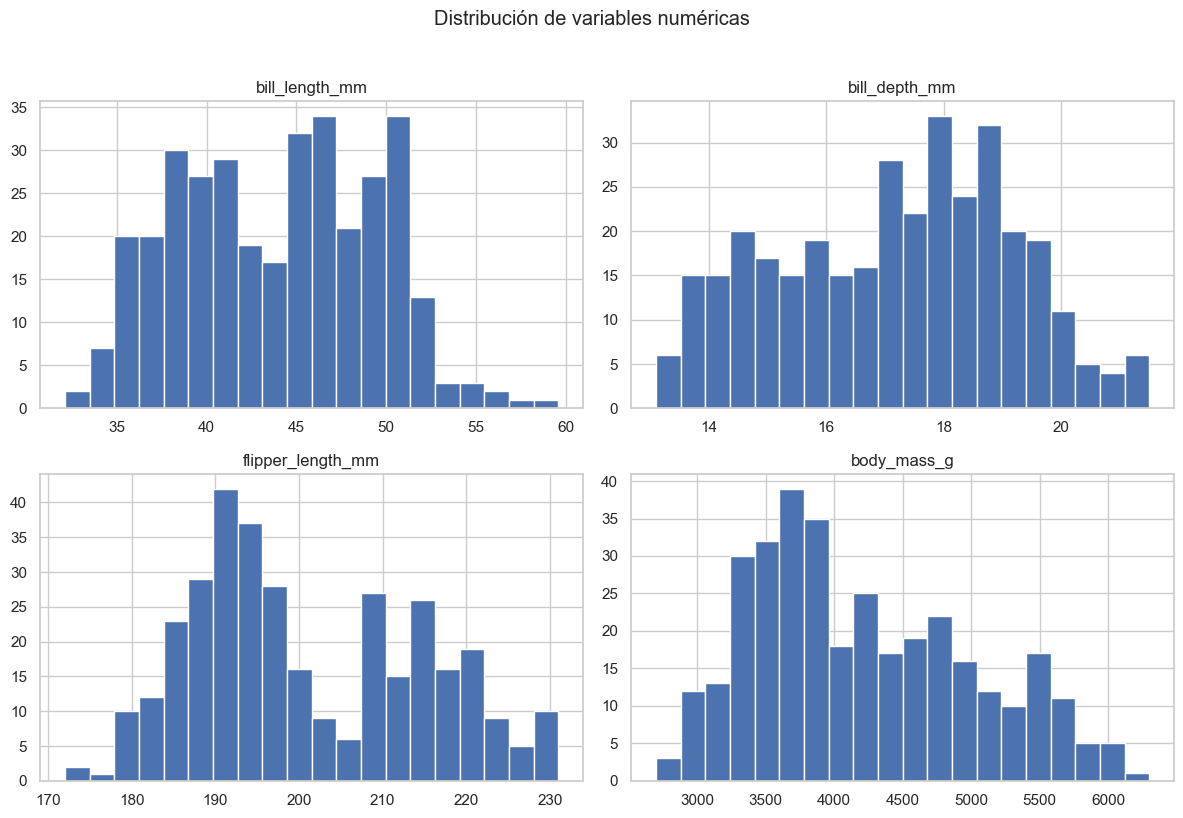

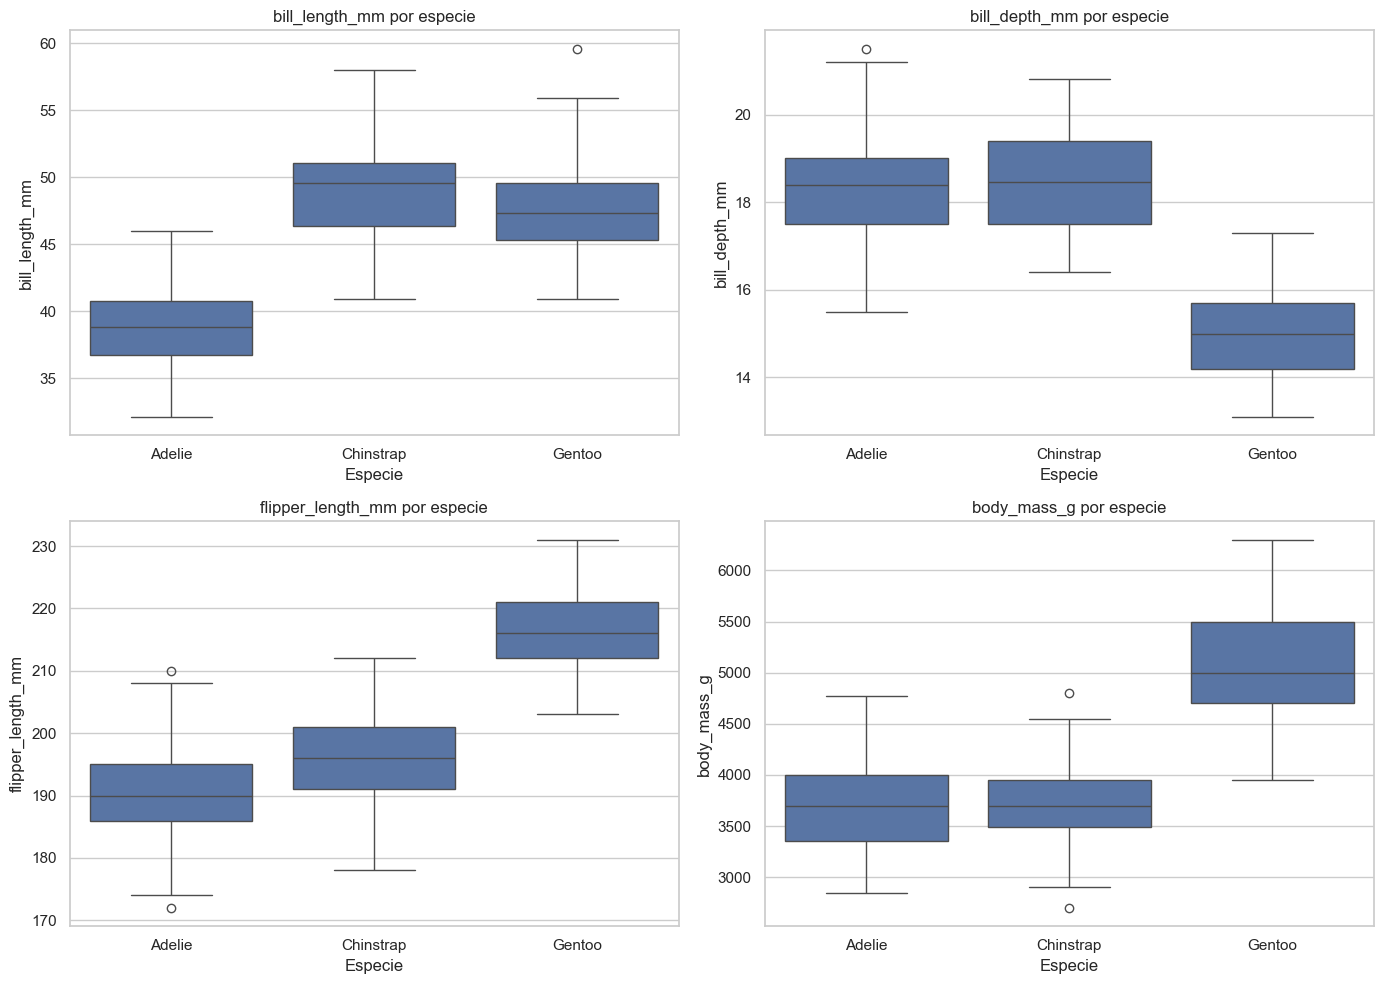

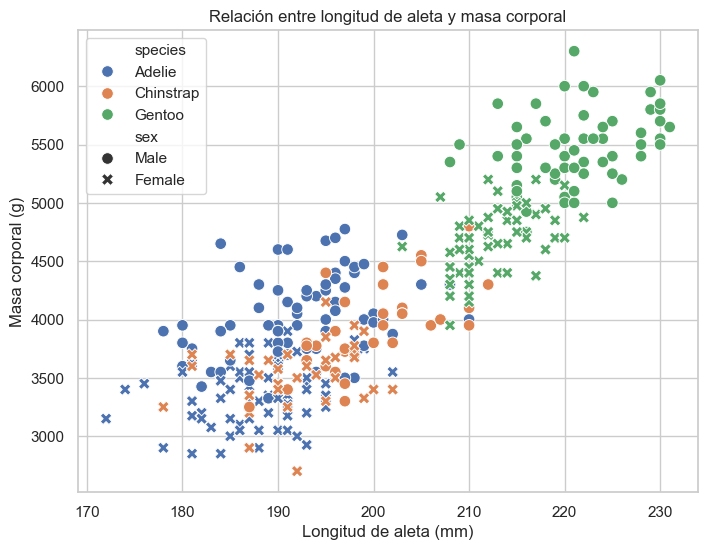

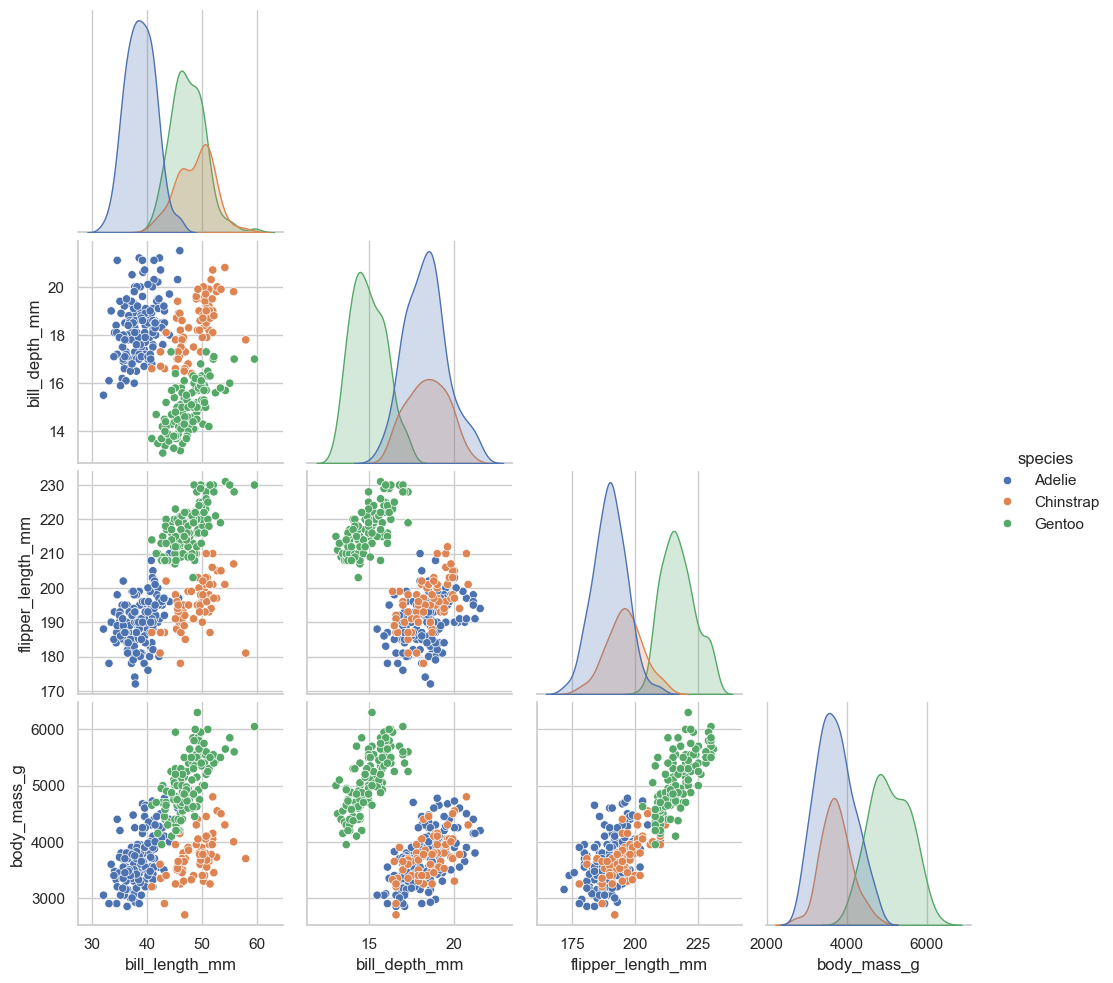

In [9]:
# --------------------------------------------
# 7. Diferencias preliminares en medidas físicas
# --------------------------------------------
display(Markdown("## 7. Visualización preliminar de medidas físicas"))

# Histogramas
df[vars_numericas].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

# Boxplots por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, var in zip(axes, vars_numericas):
    sns.boxplot(data=df, x="species", y=var, ax=ax)
    ax.set_title(f"{var} por especie")
    ax.set_xlabel("Especie")
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()

# Scatterplot relevante
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    style="sex",
    s=70
)
plt.title("Relación entre longitud de aleta y masa corporal")
plt.xlabel("Longitud de aleta (mm)")
plt.ylabel("Masa corporal (g)")
plt.show()

# Pairplot opcional para visión global
sns.pairplot(
    df[["species"] + vars_numericas].dropna(),
    hue="species",
    corner=True
)
plt.show()

In [10]:
# --------------------------------------------
# 8. Tabla resumen por especie
# --------------------------------------------
display(Markdown("## 8. Resumen de medidas físicas por especie"))
resumen_especie = (
    df.groupby("species")[vars_numericas]
    .agg(["mean", "std", "median"])
    .round(2)
)
display(resumen_especie)

## 8. Resumen de medidas físicas por especie

bill_length_mm             bill_depth_mm              \
                    mean  std median          mean  std median   
species                                                          
Adelie             38.79 2.66  38.80         18.35 1.22  18.40   
Chinstrap          48.83 3.34  49.55         18.42 1.14  18.45   
Gentoo             47.50 3.08  47.30         14.98 0.98  15.00   

          flipper_length_mm             body_mass_g                  
                       mean  std median        mean    std   median  
species                                                              
Adelie               189.95 6.54 190.00    3,700.66 458.57 3,700.00  
Chinstrap            195.82 7.13 196.00    3,733.09 384.34 3,700.00  
Gentoo               217.19 6.48 216.00    5,076.02 504.12 5,000.00

In [11]:
# --------------------------------------------
# 9. Texto interpretativo automático (base)
# --------------------------------------------
means = df.groupby("species")[vars_numericas].mean()

especie_mas_pesada = means["body_mass_g"].idxmax()
especie_menos_pesada = means["body_mass_g"].idxmin()

especie_aleta_larga = means["flipper_length_mm"].idxmax()
especie_pico_largo = means["bill_length_mm"].idxmax()
especie_pico_profundo = means["bill_depth_mm"].idxmax()

texto_1 = f"""
El dataset **penguins** contiene **{n_obs} observaciones** y **{n_vars} variables**. 
Se identifican variables **numéricas** asociadas a medidas físicas del pingüino 
(`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`) y variables 
**categóricas** como la especie, la isla y el sexo. La revisión inicial muestra la 
presencia de valores ausentes en algunas variables, especialmente en `sex` y en ciertas 
medidas físicas, por lo que será necesario tenerlo en cuenta en fases posteriores del análisis.
"""

texto_2 = f"""
En cuanto a la composición del dataset, la variable `species` muestra que las observaciones 
se distribuyen entre las especies **Adelie**, **Chinstrap** y **Gentoo**, con una representación 
no completamente uniforme. Desde una perspectiva descriptiva preliminar, se observan diferencias 
físicas entre especies: **{especie_mas_pesada}** presenta, en promedio, mayor masa corporal, 
mientras que **{especie_aleta_larga}** destaca por una mayor longitud de aleta. Asimismo, 
**{especie_pico_largo}** muestra el pico más largo en media y **{especie_pico_profundo}** la 
mayor profundidad de pico. Estos resultados sugieren desde el inicio una estructura morfológica 
diferenciada, lo que justifica el uso posterior de técnicas como ACP y clustering.
"""

display(Markdown("## 9. Lectura interpretativa preliminar"))
display(Markdown(texto_1))
display(Markdown(texto_2))

## 9. Lectura interpretativa preliminar


El dataset **penguins** contiene **344 observaciones** y **7 variables**. 
Se identifican variables **numéricas** asociadas a medidas físicas del pingüino 
(`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`) y variables 
**categóricas** como la especie, la isla y el sexo. La revisión inicial muestra la 
presencia de valores ausentes en algunas variables, especialmente en `sex` y en ciertas 
medidas físicas, por lo que será necesario tenerlo en cuenta en fases posteriores del análisis.



En cuanto a la composición del dataset, la variable `species` muestra que las observaciones 
se distribuyen entre las especies **Adelie**, **Chinstrap** y **Gentoo**, con una representación 
no completamente uniforme. Desde una perspectiva descriptiva preliminar, se observan diferencias 
físicas entre especies: **Gentoo** presenta, en promedio, mayor masa corporal, 
mientras que **Gentoo** destaca por una mayor longitud de aleta. Asimismo, 
**Chinstrap** muestra el pico más largo en media y **Chinstrap** la 
mayor profundidad de pico. Estos resultados sugieren desde el inicio una estructura morfológica 
diferenciada, lo que justifica el uso posterior de técnicas como ACP y clustering.
